In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error , r2_score

In [2]:
np.random.seed(42)
n = 200
x = np.linspace(-3 , 3 , n)
X = x.reshape(-1 , 1)
y_true = 0.5 * x ** 3 - x
y = y_true + np.random.normal(0 , 1.0 , n)
degrees = [1 , 2 , 3]
predictions = {}
residuals = {}
metrics = []

In [3]:
for deg in degrees:
    poly = PolynomialFeatures(degree = deg , include_bias = False)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    model.fit(X_poly , y)
    y_pred = model.predict(X_poly)
    predictions[deg] = y_pred
    residuals[deg] = y - y_pred
    metrics.append({"degree": deg ,
                    "mse": mean_squared_error(y , y_pred) ,
                    "r2": r2_score(y , y_pred)})
mse_vals = [m["mse"] for m in metrics]
r2_vals = [m["r2"] for m in metrics]
deg_labels = [f"d = {m['degree']}" for m in metrics]

LinearRegression()

LinearRegression()

LinearRegression()

In [4]:
def moving_average(arr , window = 15):
    kernel = np.ones(window) / window
    return np.convolve(arr , kernel , mode = "same")
resid_trend_d1 = moving_average(residuals[1] , window = 15)
resid_trend_d3 = moving_average(residuals[3] , window = 15)

<Figure size 900x550 with 0 Axes>

Text(0.5, 1.0, 'Linear vs Nonlinear Regression')

Text(0.5, 0, 'X')

Text(0, 0.5, 'y')

Text(0.02, 0.98, 'Degree 1 MSE ≈ 4.824\nDegree 3 MSE ≈ 0.851')

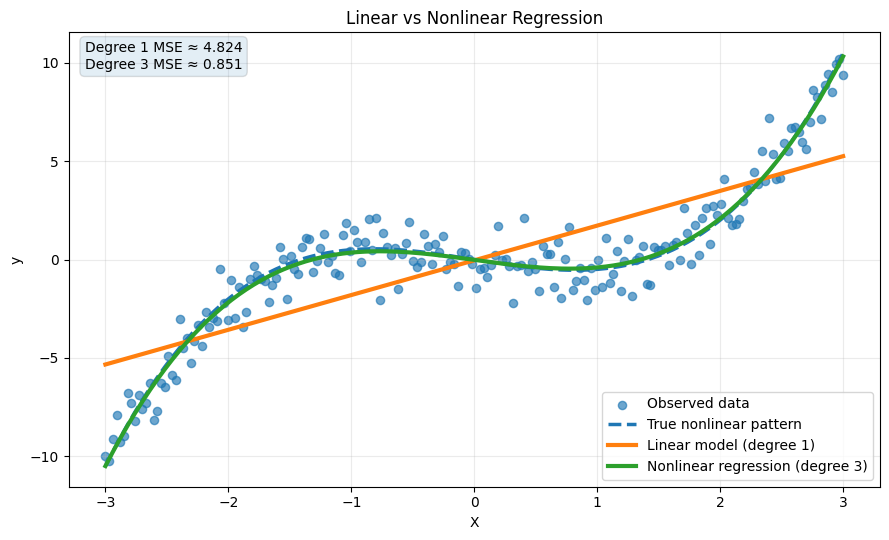

In [5]:
plt.figure(figsize = (9 , 5.5))
plt.scatter(x , y , alpha = 0.65 , s = 35 , label = "Observed data")
plt.plot(x , y_true , linestyle = "--" , linewidth = 2.5 , label = "True nonlinear pattern")
plt.plot(x , predictions[1] , linewidth = 3 , label = "Linear model (degree 1)")
plt.plot(x , predictions[3] , linewidth = 3 , label = "Nonlinear regression (degree 3)")
plt.title("Linear vs Nonlinear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(alpha = 0.25)
plt.legend()
plt.text(
    0.02 , 0.98 ,
    f"Degree 1 MSE ≈ {metrics[0]['mse']:.3f}\nDegree 3 MSE ≈ {metrics[2]['mse']:.3f}" ,
    transform = plt.gca().transAxes , va = "top" ,
    bbox = dict(boxstyle = "round , pad = 0.35" , alpha = 0.12)
)
plt.tight_layout()
plt.show()

Text(0.5, 0.98, 'Residuals show whether structure is still missing')

Text(0.5, 1.0, 'Degree 1')

Text(0.5, 0, 'X')

Text(0, 0.5, 'Residual')

Text(0.5, 1.0, 'Degree 3')

Text(0.5, 0, 'X')

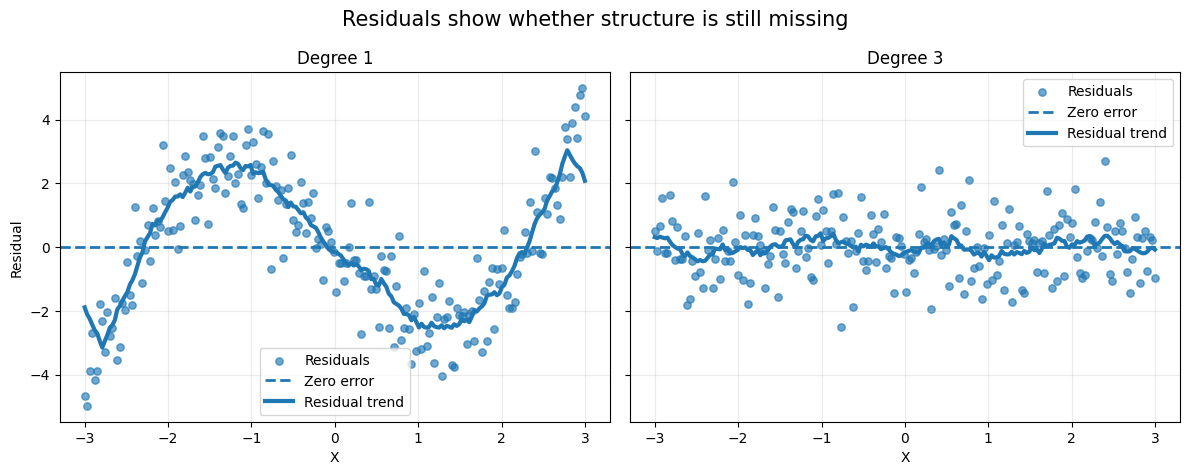

In [6]:
fig , axes = plt.subplots(1 , 2 , figsize = (12 , 4.8) , sharey = True)
fig.suptitle("Residuals show whether structure is still missing" , fontsize = 15)
axes[0].scatter(x , residuals[1] , alpha = 0.65 , s = 28 , label = "Residuals")
axes[0].axhline(0 , linestyle = "--" , linewidth = 2 , label = "Zero error")
axes[0].plot(x , resid_trend_d1 , linewidth = 3 , label = "Residual trend")
axes[0].set_title("Degree 1")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Residual")
axes[0].grid(alpha = 0.25)
axes[0].legend()
axes[1].scatter(x , residuals[3] , alpha = 0.65 , s = 28 , label = "Residuals")
axes[1].axhline(0 , linestyle = "--" , linewidth = 2 , label = "Zero error")
axes[1].plot(x , resid_trend_d3 , linewidth = 3 , label = "Residual trend")
axes[1].set_title("Degree 3")
axes[1].set_xlabel("X")
axes[1].grid(alpha = 0.25)
axes[1].legend()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Training MSE by feature degree')

Text(0, 0.5, 'MSE')

Text(0.0, 4.853597448186808, '4.82')

Text(1.0, 4.853160532060654, '4.82')

Text(2.0, 0.8814357613602236, '0.85')

Text(0.5, 1.0, 'R-Sq by feature degree')

Text(0, 0.5, 'R-Sq')

Text(0.0, 0.6718268481986395, '0.66')

Text(1.0, 0.6718574795490044, '0.66')

Text(2.0, 0.9503074742309162, '0.94')

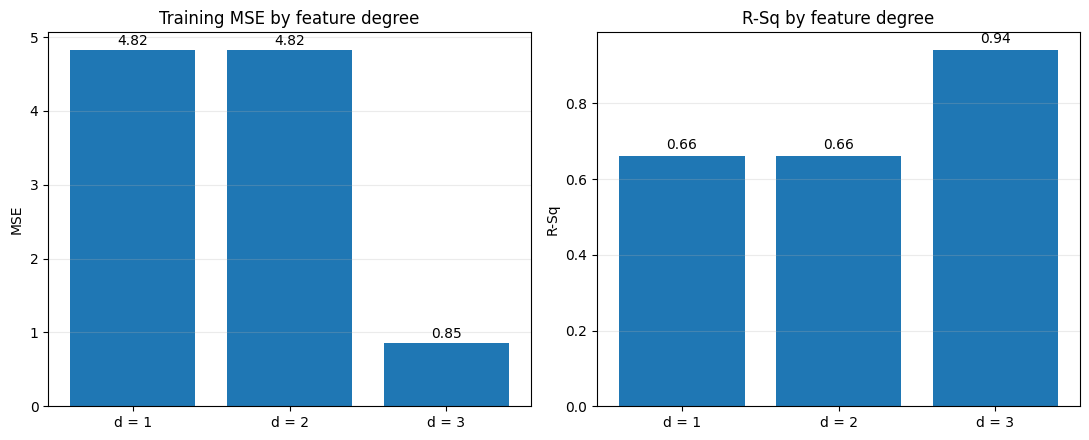

In [7]:
fig , axes = plt.subplots(1 , 2 , figsize = (11 , 4.5))
bars1 = axes[0].bar(deg_labels , mse_vals)
axes[0].set_title("Training MSE by feature degree")
axes[0].set_ylabel("MSE")
axes[0].grid(axis = "y" , alpha = 0.25)
for bar , val in zip(bars1 , mse_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2 , bar.get_height() + 0.03 ,
                 f"{val:.2f}" , ha = "center" , va = "bottom")
bars2 = axes[1].bar(deg_labels , r2_vals)
axes[1].set_title("R-Sq by feature degree")
axes[1].set_ylabel("R-Sq")
axes[1].grid(axis = "y" , alpha = 0.25)
for bar , val in zip(bars2 , r2_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2 , bar.get_height() + 0.01 ,
                 f"{val:.2f}" , ha = "center" , va = "bottom")
plt.tight_layout()
plt.show()

<Figure size 900x520 with 0 Axes>

Text(0.5, 1.0, 'Same regression model, different feature spaces')

Text(0.5, 0, 'X')

Text(0, 0.5, 'y')

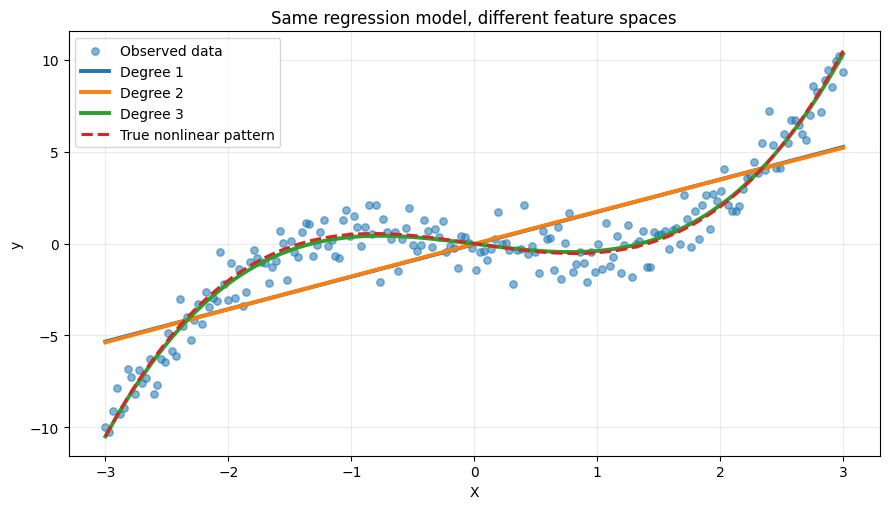

In [8]:
plt.figure(figsize = (9 , 5.2))
plt.scatter(x , y , alpha = 0.55 , s = 28 , label = "Observed data")
plt.plot(x , predictions[1] , linewidth = 2.8 , label = "Degree 1")
plt.plot(x , predictions[2] , linewidth = 2.8 , label = "Degree 2")
plt.plot(x , predictions[3] , linewidth = 2.8 , label = "Degree 3")
plt.plot(x , y_true , linestyle = "--" , linewidth = 2.2 , label = "True nonlinear pattern")
plt.title("Same regression model, different feature spaces")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(alpha = 0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
print("Day 16 Summary")
for m in metrics:
    print(f"Degree {m['degree']}: MSE = {m['mse']:.3f} , R^2 = {m['r2']:.3f}")
print("\nKey takeaway:")
print("The model is still linear regression.")
print("What changed is the feature space.")
print("That is the practical entry point to nonlinear regression.")

Day 16 Summary
Degree 1: MSE = 4.824 , R^2 = 0.662
Degree 2: MSE = 4.823 , R^2 = 0.662
Degree 3: MSE = 0.851 , R^2 = 0.940

Key takeaway:
The model is still linear regression.
What changed is the feature space.
That is the practical entry point to nonlinear regression.
